In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.interpolate import griddata
from tabulate import tabulate
from skimage.metrics import structural_similarity as ssim
import scipy.ndimage as ndimage
from skimage.draw import polygon
from tqdm import tqdm
from scipy.ndimage import distance_transform_edt

# Reproducibility of the code
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Training Parameters
num_epochs = 325
batch_size = 128
learning_rate = 0.0001

In [2]:
# Code for Research Paper Quality Graphs
import matplotlib as mpl

def set_plot_params():
    """
    Matplotlib's rcParams for consistent, publication-quality plots.
    """
    ## Figure settings
    mpl.rcParams['figure.figsize'] = (8, 6)       # Figure size in inches
    mpl.rcParams['figure.dpi'] = 100              # (Display) Figure resolution
    mpl.rcParams['savefig.dpi'] = 300             # Resolution when saving figures

    ## Font settings (Standard 16-14-12 config.)
    mpl.rcParams['font.family'] = 'serif'         # Serif fonts
    mpl.rcParams['font.size'] = 12                # Base font size
    mpl.rcParams['axes.titlesize'] = 16           # Title font size for axes
    mpl.rcParams['axes.labelsize'] = 14           # Font size for x and y labels
    mpl.rcParams['xtick.labelsize'] = 12          # Font size for x-tick labels
    mpl.rcParams['ytick.labelsize'] = 12          # Font size for y-tick labels
    mpl.rcParams['legend.fontsize'] = 12          # Legend font size

    ## Line settings
    mpl.rcParams['lines.linewidth'] = 2           # Default line width
    mpl.rcParams['lines.markersize'] = 6          # Marker size for plots

    ## Contour plot settings
    mpl.rcParams['contour.negative_linestyle'] = 'solid'

    ## Grid settings
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5

    ## Color presets (Plasma-ish color scheme)
    mpl.rcParams['image.cmap'] = 'plasma' # Can be changed to "jet", "viridis", etc.

    ## Default color cycle for line plots using the plasma colormap.
    plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.
    num_colors = 10
    colors = [plasma_cmap(i) for i in np.linspace(0, 1, num_colors)]
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

In [3]:
def compute_mae(S_exact, S_approx):
    return np.mean(np.abs(S_exact - S_approx))

In [4]:
def compute_fourier_mse(S_exact, S_approx):
    F_exact = np.fft.fft2(S_exact)
    F_approx = np.fft.fft2(S_approx)
    return np.mean(np.abs(F_exact - F_approx) ** 2)

In [5]:
def relative_l2_error(original: np.ndarray, approx: np.ndarray) -> float:

    return np.linalg.norm(original - approx, 'fro') / np.linalg.norm(original, 'fro')

def compute_error_stats(original: np.ndarray, approx: np.ndarray):

    errors = relative_l2_error(original, approx)

    return np.mean(errors)

In [6]:
def compute_psnr(original, compressed):

    assert original.shape == compressed.shape, "Matrices must have the same shape."

    mse = np.mean((original - compressed) ** 2)
    if mse == 0:  
        return float('inf')

    max_pixel = np.max(original)
    psnr = 10 * np.log10((max_pixel ** 2) / mse)

    return psnr

In [7]:
def compute_mse(matrix1, matrix2):

    assert matrix1.shape == matrix2.shape, "Matrices must have the same shape."

    mse = np.sum((matrix1 - matrix2) ** 2) / matrix1.size

    return mse

In [8]:
def compute_ssim(matrix1, matrix2):

  if matrix1.shape != matrix2.shape:
    raise ValueError("Matrices must have the same dimensions")

  ssim_value = ssim(matrix1, matrix2, data_range=matrix2.max() - matrix2.min())

  return ssim_value

In [9]:
def naca4_series(m, p, t, num_points=100):
    
    x = np.linspace(0, 1, num_points) 
    if p == 0:
        yc = np.zeros_like(x)
        dyc_dx = np.zeros_like(x)
    else:
        yc = np.where(x < p, (m / p**2) * (2 * p * x - x**2), 
                      (m / (1 - p)**2) * ((1 - 2*p) + 2*p*x - x**2))
        dyc_dx = np.where(x < p, (2 * m / p**2) * (p - x),
                          (2 * m / (1 - p)**2) * (p - x))

    theta = np.arctan(dyc_dx)

    yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1036 * x**4)

    xu = x - yt * np.sin(theta)
    xl = x + yt * np.sin(theta)
    yu = yc + yt * np.cos(theta)
    yl = yc - yt * np.cos(theta)

    X = np.concatenate((xu, xl[::-1]))
    Y = np.concatenate((yu, yl[::-1]))

    return X, Y

def airfoil_to_large_grid(x, y, grid_size=256, airfoil_size=128):

    x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x)) * (airfoil_size - 1)
    y_scaled = (y - np.min(y)) / (np.max(y) - np.min(y)) * (airfoil_size - 1)
    x_shifted = x_scaled + (grid_size - airfoil_size) // 2
    y_shifted = y_scaled + (grid_size - airfoil_size) // 2
    x_shifted = np.clip(x_shifted, 0, grid_size - 1)
    y_shifted = np.clip(y_shifted, 0, grid_size - 1)

    # Create binary mask
    img = np.ones((grid_size, grid_size), dtype=np.uint8)
    rr, cc = polygon(y_shifted, x_shifted, img.shape)
    img[rr, cc] = 0 

    return img

def compute_signed_distance(airfoil_mask):
    
    sdf_outside = distance_transform_edt(airfoil_mask)  
    sdf_inside = distance_transform_edt(1 - airfoil_mask)  

    sdf = sdf_outside - sdf_inside

    max_distance = np.max(np.abs(sdf)) 
    sdf = sdf / max_distance  

    boundary_mask = np.logical_and(airfoil_mask == 0, 
                                   np.logical_and(distance_transform_edt(airfoil_mask) > 0, 
                                                  distance_transform_edt(1 - airfoil_mask) > 0))
    sdf[boundary_mask] = 0  

    return sdf

num_airfoils = 1250
grid_size = 256  
airfoil_size = 92 

airfoil_shapes = np.zeros((num_airfoils, grid_size, grid_size), dtype=np.uint8)
sdf_solutions = np.zeros((num_airfoils, grid_size, grid_size), dtype=np.float32)

# Generate dataset
for i in tqdm(range(num_airfoils), desc="Generating NACA 4-Digit Airfoils"):

    m = random.uniform(0.01, 0.09)  
    p = random.uniform(0.1, 0.7)  
    t = random.uniform(0.1, 0.4)

    x, y = naca4_series(m, p, t)
    airfoil_mask = airfoil_to_large_grid(x, y, grid_size, airfoil_size)
    sdf = compute_signed_distance(airfoil_mask)
    airfoil_shapes[i, :, :] = airfoil_mask
    sdf_solutions[i, :, :] = sdf

np.save("airfoil_shapes.npy", airfoil_shapes)
np.save("sdf_solutions.npy", sdf_solutions)

print("Dataset generation complete!")

Generating NACA 4-Digit Airfoils: 100%|██████████| 1250/1250 [00:09<00:00, 135.44it/s]


Dataset generation complete!


In [10]:
a_samples = np.load('airfoil_shapes.npy')
u_samples = np.load('sdf_solutions.npy')

C:\Users\asojitra\AppData\Local\Temp\ipykernel_22208\2134351153.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


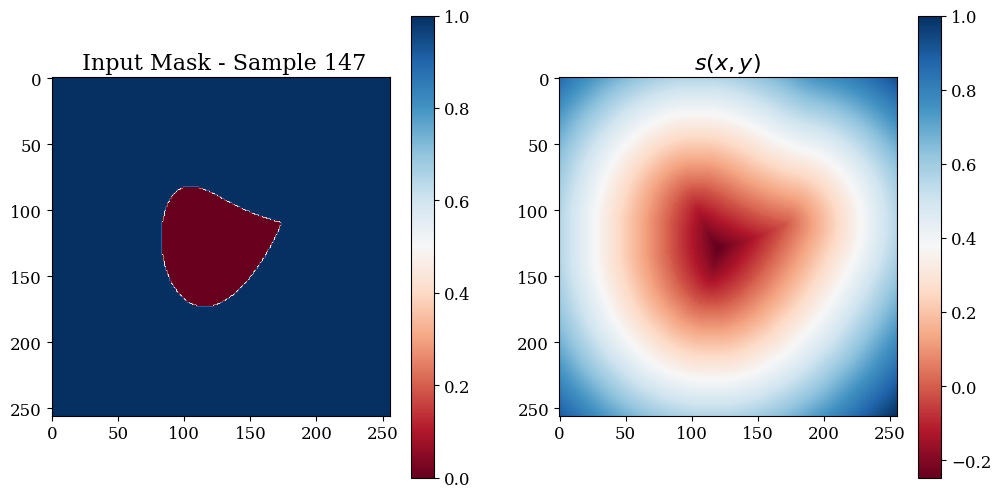

In [11]:
sample_idx = random.randint(0, u_samples.shape[0])
set_plot_params()
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
plt.title('$s(x,y)$ ')
plt.imshow(u_samples[sample_idx], cmap='RdBu')
plt.colorbar()

plt.subplot(1, 2, 1)
plt.title(f' Input Mask - Sample {sample_idx}')
plt.imshow(a_samples[sample_idx], cmap='RdBu')
plt.colorbar()

plt.show()

In [12]:
velocity_fields = u_samples 
input_coefficients = a_samples 

X_train, X_test, y_train, y_test = train_test_split(
    input_coefficients, velocity_fields, test_size=0.2, random_state=42
)

In [13]:
class PoissonDataset(Dataset):
    def __init__(self, velocity_fields, input_coefficients):
        self.velocity_fields = torch.tensor(velocity_fields, dtype=torch.float32).unsqueeze(1)
        self.input_coefficients = torch.tensor(input_coefficients, dtype=torch.float32).unsqueeze(1)

        self.grid_size = self.velocity_fields.shape[-1]
        grid = np.linspace(0, 1, self.grid_size)
        self.X, self.Y = np.meshgrid(grid, grid)
        self.coords = np.stack([self.X, self.Y], axis=-1)
        self.coords = torch.tensor(self.coords, dtype=torch.float32)

    def __len__(self):
        return self.velocity_fields.shape[0]

    def __getitem__(self, idx):
        velocity = self.velocity_fields[idx]
        coeff = self.input_coefficients[idx]
        return velocity, coeff

In [14]:
## DeepONet with CNNs
class BranchNet(nn.Module):
    def __init__(self):
        super(BranchNet, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*16*16*4, 128),
            nn.ReLU(),
            nn.Linear(128, 100),
        )

    def forward(self, x):
        return self.conv_layers(x)

class TrunkNet(nn.Module):
    def __init__(self):
        super(TrunkNet, self).__init__()
        self.fc_layers = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 100),
        )

    def forward(self, coords):
        coords = coords.view(-1, 2)
        return self.fc_layers(coords)
    
    

class DeepONet(nn.Module):
    def __init__(self):
        super(DeepONet, self).__init__()
        self.branch_net = BranchNet()
        self.trunk_net = TrunkNet()

    def forward(self, velocity, coords):

        batch_size = velocity.size(0)
        grid_size = coords.size(0)
       
        coords_flat = coords.view(-1, 2)
        trunk_out = self.trunk_net(coords_flat)
        branch_out = self.branch_net(velocity)
        outputs = torch.matmul(branch_out, trunk_out.T)
        outputs = outputs.view(batch_size, 1, grid_size, grid_size)

        return outputs

In [15]:
## Train Hyperparameters
train_dataset = PoissonDataset(X_train, y_train)
test_dataset = PoissonDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepONet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [16]:
## Train function
def train(model, loader, optimizer, criterion, device, coords):
    model.train()
    running_loss = 0.0
    for velocity, coeff in loader:
        velocity = velocity.to(device)
        coeff = coeff.to(device)

        optimizer.zero_grad()
        outputs = model(velocity, coords.to(device))
        loss = criterion(outputs, coeff)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * velocity.size(0)
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [17]:
def evaluate(model, loader, criterion, device, coords):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for velocity, coeff in loader:
            velocity = velocity.to(device)
            coeff = coeff.to(device)

            outputs = model(velocity, coords.to(device))
            loss = criterion(outputs, coeff)
            running_loss += loss.item() * velocity.size(0)
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [ ]:
train_losses = []
test_losses = []

coords = train_dataset.coords.to(device)

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, device, coords)
    test_loss = evaluate(model, test_loader, criterion, device, coords)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.12f}, '
          f'Test Loss: {test_loss:.12f}')

C:\Users\asojitra\AppData\Local\Temp\ipykernel_22208\2134351153.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


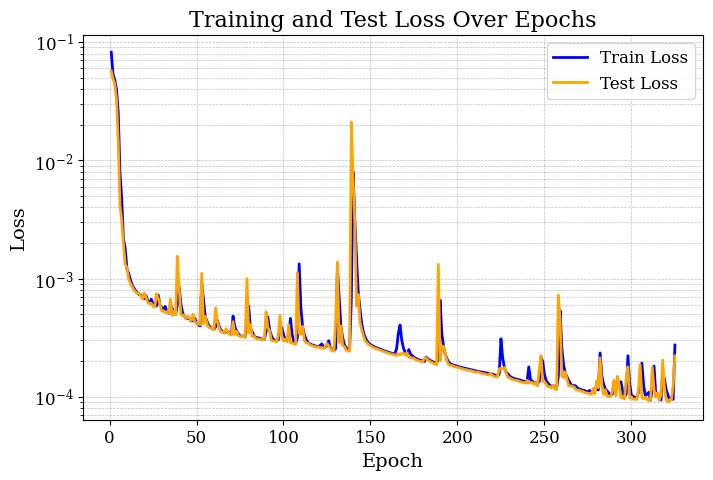

In [19]:
set_plot_params()
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, num_epochs+1), train_losses, 'b-', label='Train Loss')
plt.semilogy(range(1, num_epochs+1), test_losses, color='orange', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

In [20]:
# Trunk Net Model
class FourierEmbedding(nn.Module):

    # Fourier Feature Mapping
    def __init__(self, input_dim, mapping_size=512):
        super().__init__()
        self.B = torch.randn(input_dim, mapping_size) * 10.0

    def forward(self, x):
        x_proj = 2 * np.pi * x @ self.B.to(x.device)
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class BranchNet_new(nn.Module):
    def __init__(self):
        super(BranchNet_new, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*16*16*4, 128),
            nn.ReLU(),
            nn.Linear(128, 100),
        )

    def forward(self, x):
        return self.conv_layers(x)

class TrunkNet_new(nn.Module):

    # Based on the Fourier Embedding defined above
    def __init__(self, input_dim):
        super().__init__()
        self.fourier_embed = FourierEmbedding(input_dim)
        self.fc = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 100),
        )

    def forward(self, x):
        x = self.fourier_embed(x)
        return self.fc(x)



class DeepONet_new(nn.Module):
    def __init__(self):
        super(DeepONet_new, self).__init__()

        self.branch_net_new = BranchNet_new()
        self.trunk_net_new = TrunkNet_new(input_dim = 2)

    def forward(self, velocity, coords):

        batch_size = velocity.size(0)
        grid_size = coords.size(0)
        H_W = grid_size * grid_size
        coords_flat = coords.view(-1, 2)
        trunk_out_new = self.trunk_net_new(coords_flat)
        branch_out_new = self.branch_net_new(velocity)
        outputs = torch.matmul(branch_out_new, trunk_out_new.T)
        outputs = outputs.view(batch_size, 1, grid_size, grid_size)

        return outputs

In [21]:
## Train Hyperparameters
train_dataset = PoissonDataset(X_train, y_train)
test_dataset = PoissonDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_new = DeepONet_new().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_new.parameters(), lr=learning_rate)

In [ ]:
train_losses = []
test_losses = []
coords = train_dataset.coords.to(device)

for epoch in range(num_epochs):
    train_loss = train(model_new, train_loader, optimizer, criterion, device, coords)
    test_loss = evaluate(model_new, test_loader, criterion, device, coords)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.12f}, '
          f'Test Loss: {test_loss:.12f}')

C:\Users\asojitra\AppData\Local\Temp\ipykernel_22208\2134351153.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


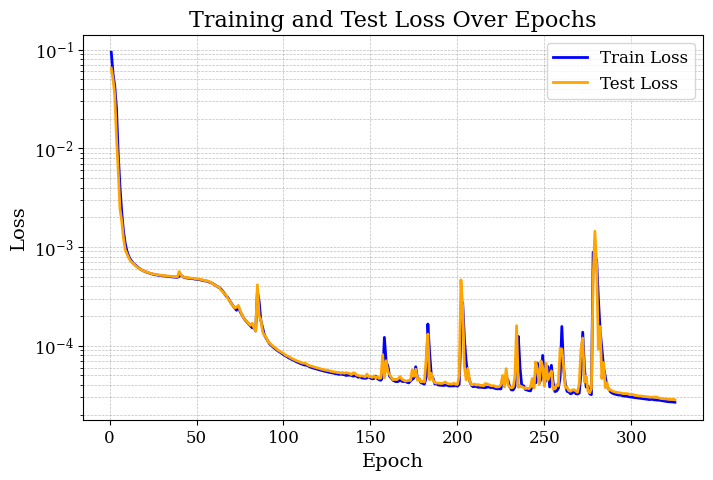

In [23]:
set_plot_params()
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, num_epochs+1), train_losses, 'b-', label='Train Loss')
plt.semilogy(range(1, num_epochs+1), test_losses, color='orange', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

In [24]:
velocity, coeff = next(iter(test_loader))
velocity = velocity.to(device)
coeff = coeff.to(device)

model.eval()
model_new.eval()
with torch.no_grad():
    outputs = model(velocity, coords.to(device))
    outputs_new = model_new(velocity, coords.to(device))

velocity = velocity.cpu().numpy()
coeff = coeff.cpu().numpy()
outputs = outputs.cpu().numpy()
outputs_new = outputs_new.cpu().numpy()

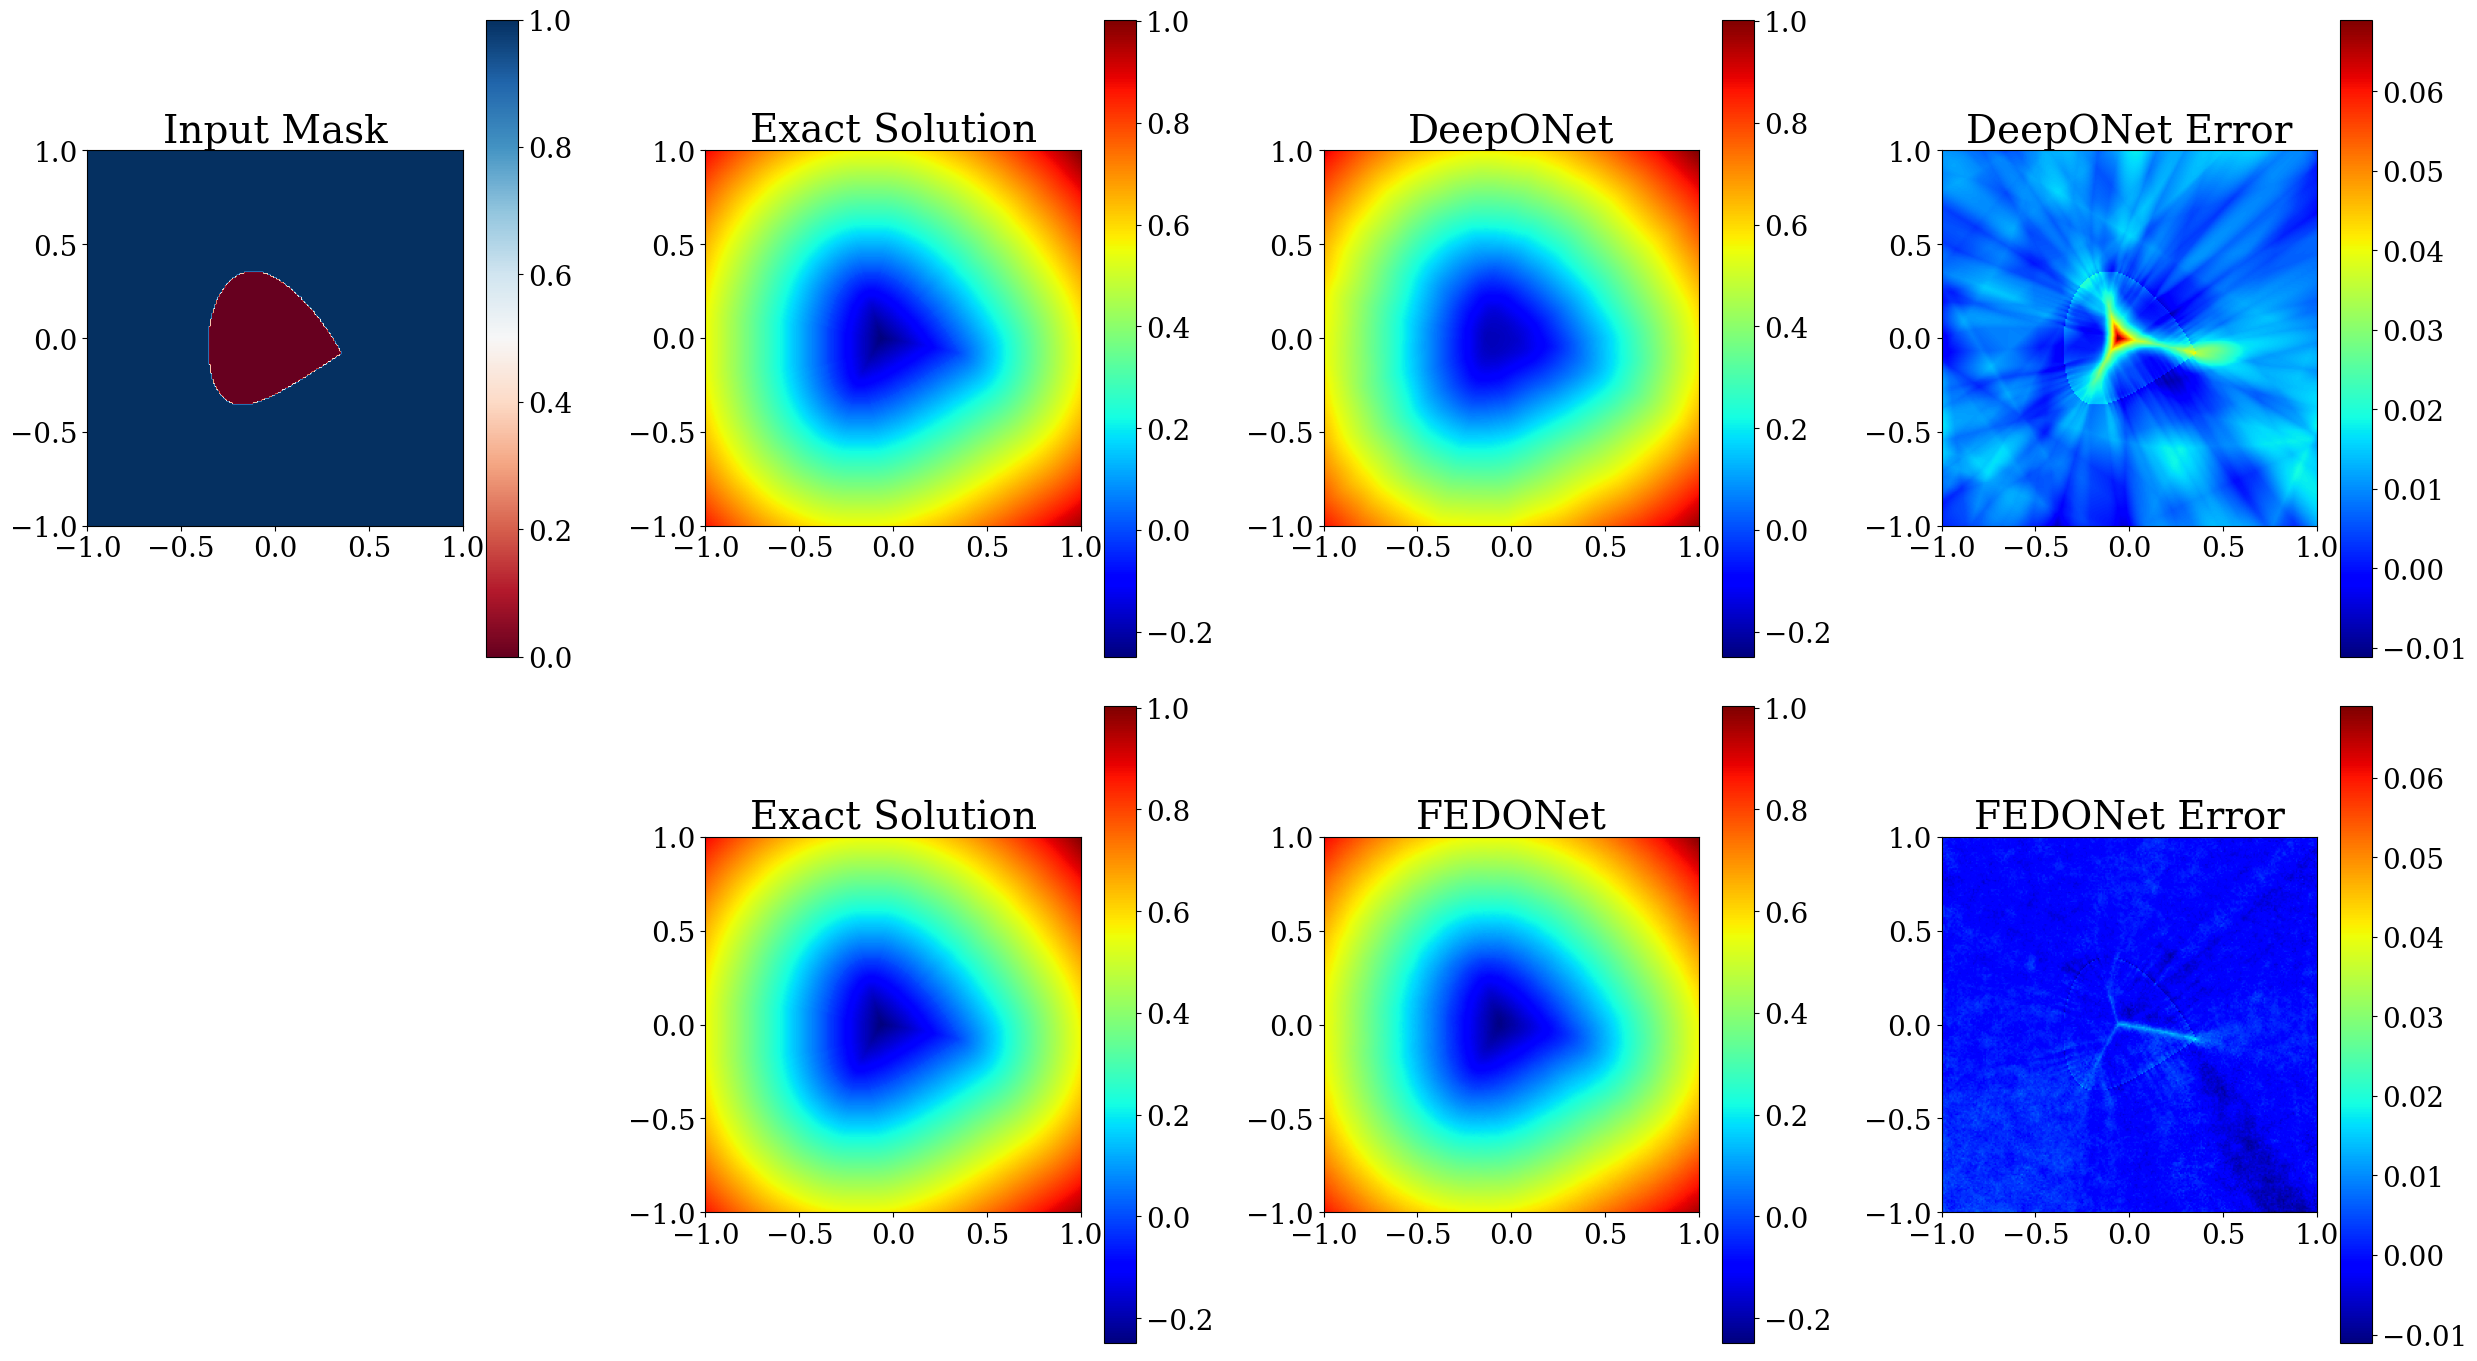

In [35]:
# ============================================================
# VISUALIZATION (DeepONet vs FEDONet)
# Same arrangement pattern as requested
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# Choose sample
# You can change this selection rule if you want
# ------------------------------------------------------------
# idx = np.random.randint(0, velocity.shape[0])
idx = 55

input_field = velocity
full_solution = coeff
outputs_van = outputs
outputs_fed = outputs_new

# ------------------------------------------------------------
# Plot parameters
# ------------------------------------------------------------
def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})

plt.rcParams['image.cmap'] = 'jet'

# ------------------------------------------------------------
# Grid / extent
# ------------------------------------------------------------
extent = [-1, 1, -1, 1]

# ------------------------------------------------------------
# Errors
# ------------------------------------------------------------
error_van = outputs_van[idx, 0] - full_solution[idx, 0]
error_fed = outputs_fed[idx, 0] - full_solution[idx, 0]

vmin_sol = min(
    full_solution[idx, 0].min(),
    outputs_van[idx, 0].min(),
    outputs_fed[idx, 0].min()
)
vmax_sol = max(
    full_solution[idx, 0].max(),
    outputs_van[idx, 0].max(),
    outputs_fed[idx, 0].max()
)

vmin_err = min(error_van.min(), error_fed.min())
vmax_err = max(error_van.max(), error_fed.max())

vmin_inp = input_field[idx, 0].min()
vmax_inp = input_field[idx, 0].max()

# ============================================================
# Plot
# ============================================================
fig = plt.figure(figsize=(25, 14))

# ---- Input mask ----
ax0 = fig.add_subplot(241)
c0 = ax0.imshow(
    input_field[idx, 0],
    cmap='RdBu',
    extent=extent,
    origin='lower',
    vmin=vmin_inp,
    vmax=vmax_inp
)
ax0.set_title('Input Mask')
fig.colorbar(c0, ax=ax0)

# ---- Exact solution ----
ax1 = fig.add_subplot(242)
c1 = ax1.imshow(
    full_solution[idx, 0],
    cmap='jet',
    extent=extent,
    origin='lower',
    vmin=vmin_sol,
    vmax=vmax_sol
)
ax1.set_title('Exact Solution')
fig.colorbar(c1, ax=ax1)

# ---- DeepONet prediction ----
ax2 = fig.add_subplot(243)
c2 = ax2.imshow(
    outputs_van[idx, 0],
    cmap='jet',
    extent=extent,
    origin='lower',
    vmin=vmin_sol,
    vmax=vmax_sol
)
ax2.set_title('DeepONet')
fig.colorbar(c2, ax=ax2)

# ---- DeepONet error ----
ax3 = fig.add_subplot(244)
c3 = ax3.imshow(
    error_van,
    cmap='jet',
    extent=extent,
    origin='lower',
    vmin=vmin_err,
    vmax=vmax_err
)
ax3.set_title('DeepONet Error')
fig.colorbar(c3, ax=ax3)

# ---- Exact solution again ----
ax5 = fig.add_subplot(246)
c5 = ax5.imshow(
    full_solution[idx, 0],
    cmap='jet',
    extent=extent,
    origin='lower',
    vmin=vmin_sol,
    vmax=vmax_sol
)
ax5.set_title('Exact Solution')
fig.colorbar(c5, ax=ax5)

# ---- FEDONet prediction ----
ax6 = fig.add_subplot(247)
c6 = ax6.imshow(
    outputs_fed[idx, 0],
    cmap='jet',
    extent=extent,
    origin='lower',
    vmin=vmin_sol,
    vmax=vmax_sol
)
ax6.set_title('FEDONet')
fig.colorbar(c6, ax=ax6)

# ---- FEDONet error ----
ax7 = fig.add_subplot(248)
c7 = ax7.imshow(
    error_fed,
    cmap='jet',
    extent=extent,
    origin='lower',
    vmin=vmin_err,
    vmax=vmax_err
)
ax7.set_title('FEDONet Error')
fig.colorbar(c7, ax=ax7)

plt.tight_layout()
plt.show()

In [36]:
data_for_table = [
              ["MAE", compute_mae(coeff[idx, 0], outputs[idx, 0]), compute_mae(coeff[idx, 0], outputs_new[idx, 0])], 
              ["MSE", compute_mse(coeff[idx, 0], outputs[idx, 0]), compute_mse(coeff[idx, 0], outputs_new[idx, 0])],
              ["SSIM", compute_ssim(coeff[idx, 0], outputs[idx, 0]), compute_ssim(coeff[idx, 0], outputs_new[idx, 0])],
              ["PSNR", compute_psnr(coeff[idx, 0], outputs[idx, 0]), compute_psnr(coeff[idx, 0], outputs_new[idx, 0])],
              ["Relative L2 Error (%)", compute_error_stats(coeff[idx, 0], outputs[idx, 0])*100, compute_error_stats(coeff[idx, 0], outputs_new[idx, 0])*100]
              
]

headers = ["", "Vanilla ( Original ) DeepONet", "Fourier Embedded DeepONet"]
print(tabulate(data_for_table, headers=headers, tablefmt="grid", numalign="center", stralign="center"))

+-----------------------+---------------------------------+-----------------------------+
|                       |  Vanilla ( Original ) DeepONet  |  Fourier Embedded DeepONet  |
+=======================+=================================+=============================+
|          MAE          |           0.00909693            |         0.00185271          |
+-----------------------+---------------------------------+-----------------------------+
|          MSE          |           0.000108932           |         5.81895e-06         |
+-----------------------+---------------------------------+-----------------------------+
|         SSIM          |            0.989921             |          0.998377           |
+-----------------------+---------------------------------+-----------------------------+
|         PSNR          |             39.6284             |           52.3516           |
+-----------------------+---------------------------------+-----------------------------+
| Relative

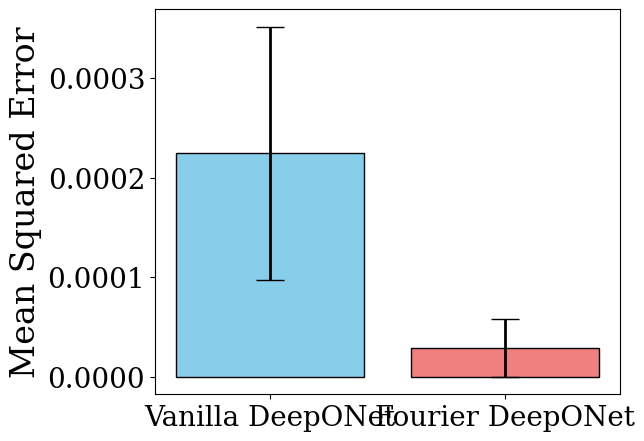

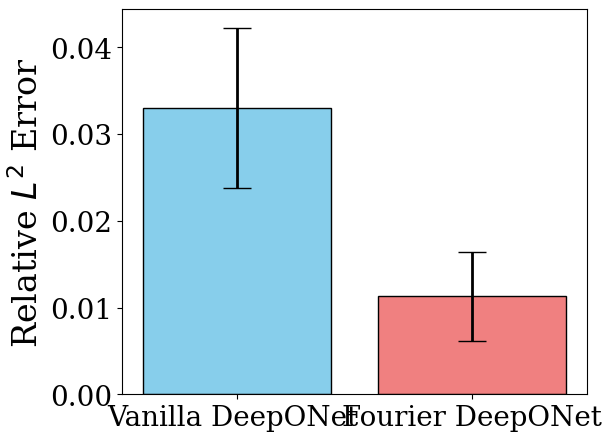

In [27]:
mse_normal_deeponet_array = np.zeros(velocity.shape[0])  
mse_fourier_deeponet_array = np.zeros(velocity.shape[0])
relative_l2_normal_deeponet_array = np.zeros(velocity.shape[0])
relative_l2_fourier_deeponet_array = np.zeros(velocity.shape[0])

for k in range(velocity.shape[0]):
    mse_normal_deeponet_array[k] = compute_mse(coeff[k, 0], outputs[k, 0])
    mse_fourier_deeponet_array[k] = compute_mse(coeff[k, 0], outputs_new[k, 0])
    relative_l2_normal_deeponet_array[k] = compute_error_stats(coeff[k, 0], outputs[k, 0])
    relative_l2_fourier_deeponet_array[k] = compute_error_stats(coeff[k, 0], outputs_new[k, 0])
    
    
# MSE plot
means = [np.mean(mse_normal_deeponet_array), np.mean(mse_fourier_deeponet_array)]
stds = [np.std(mse_normal_deeponet_array), np.std(mse_fourier_deeponet_array)]
x_labels = ["Vanilla DeepONet", "Fourier DeepONet"]
x_positions = np.arange(len(x_labels))  
plt.figure(figsize=(6, 5))
plt.bar(x_positions, means, yerr=stds, capsize=10, color=["skyblue", "lightcoral"], edgecolor="black")
plt.xticks(x_positions, x_labels)  
plt.ylabel("Mean Squared Error")
plt.show()

# Relative L2 Plot
means = [np.mean(relative_l2_normal_deeponet_array), np.mean(relative_l2_fourier_deeponet_array)]
stds = [np.std(relative_l2_normal_deeponet_array), np.std(relative_l2_fourier_deeponet_array)]
x_labels = ["Vanilla DeepONet ", "Fourier DeepONet"]
x_positions = np.arange(len(x_labels))  
plt.figure(figsize=(6, 5))
plt.bar(x_positions, means, yerr=stds, capsize=10, color=["skyblue", "lightcoral"], edgecolor="black")
plt.xticks(x_positions, x_labels) 
plt.ylabel("Relative $L^2$ Error")
plt.show()

In [28]:
# Compute mean and std
mean_rel_l2_normal = np.mean(relative_l2_normal_deeponet_array)*100
mean_rel_l2_fourier = np.mean(relative_l2_fourier_deeponet_array)*100

std_rel_l2_normal = np.std(relative_l2_normal_deeponet_array)*100
std_rel_l2_fourier = np.std(relative_l2_fourier_deeponet_array)*100

# Print results
print(f"Vanilla DeepONet Relative L2 Error: {mean_rel_l2_normal:.4e} ± {std_rel_l2_normal:.2e}")
print(f"Fourier DeepONet Relative L2 Error: {mean_rel_l2_fourier:.4e} ± {std_rel_l2_fourier:.2e}")

Vanilla DeepONet Relative L2 Error: 3.3039e+00 ± 9.25e-01
Fourier DeepONet Relative L2 Error: 1.1292e+00 ± 5.17e-01


In [34]:
# Minimum value
min_val = np.min(relative_l2_fourier_deeponet_array)

# Index of minimum (works for any shape)
min_idx = np.unravel_index(
    np.argmin(relative_l2_fourier_deeponet_array),
    relative_l2_fourier_deeponet_array.shape
)

print("Minimum value :", min_val)
print("Index :", min_idx)

Minimum value : 0.0054077273234725
Index : (np.int64(55),)
